<a href="https://colab.research.google.com/github/photochemistry/airpollutionwatch/blob/main/demo_kanagawa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kanagawa Air Pollution Grid Demo

airpollutionwatch API の `/v1/grid/field` を使い、神奈川県全域の NOX・OX・PM2.5 を地図表示します。

In [1]:
# Colab 用パッケージインストール（ローカルでは不要なら skip）
import importlib, subprocess, sys

def install(pkg):
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

for p in ['requests', 'matplotlib', 'numpy']:
    install(p)

In [2]:
import json
import numpy as np
import requests
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection

In [8]:
# ── 設定 ────────────────────────────────────────────
API_BASE  = 'http://andersan.net:8089'
BBOX      = '138.9,35.1,139.85,35.7'   # 神奈川県をカバーする bbox
DATETIME  = '2026-03-06T12:00+09:00'   # 対象時刻（ISO 8601）
SMOOTHING = 0.007
Z         = 13
POLLUTANTS = ['nox', 'ox', 'pm25']
TITLES     = ['NOX (ppb)', 'OX (ppb)', 'PM2.5 (µg/m³)']
CMAPS      = ['OrRd', 'PuBu', 'YlOrBr']

In [9]:
# ── 神奈川県の輪郭を GeoJSON から取得 ────────────────
GEOJSON_URL = 'https://raw.githubusercontent.com/dataofjapan/land/master/japan.geojson'

geo = requests.get(GEOJSON_URL, timeout=30).json()
kanagawa_geom = next(
    f['geometry']
    for f in geo['features']
    if f['properties'].get('nam_ja') == '神奈川県'
)
print('geometry type:', kanagawa_geom['type'])

def geom_to_rings(geom):
    """MultiPolygon / Polygon の exterior リングを [(lon, lat), ...] のリストで返す."""
    rings = []
    polys = geom['coordinates'] if geom['type'] == 'MultiPolygon' else [geom['coordinates']]
    for poly in polys:
        exterior = np.array(poly[0])   # [0] = exterior ring, [1:] = holes
        rings.append(exterior)
    return rings

kanagawa_rings = geom_to_rings(kanagawa_geom)
print(f'{len(kanagawa_rings)} polygon(s)')

geometry type: MultiPolygon
11 polygon(s)


In [10]:
# ── タイル座標 ↔ 緯度経度変換（grid_utils のコピー） ──
def tile_xy_to_lonlat(x, y, z):
    n = 2.0 ** z
    lon = x / n * 360.0 - 180.0
    lat = np.rad2deg(np.arctan(np.sinh(np.pi * (1.0 - 2.0 * y / n))))
    return lon, lat

def lonlat_to_tile_xy(lon, lat, z):
    n = 2.0 ** z
    x = (lon + 180.0) / 360.0 * n
    lat_r = np.deg2rad(lat)
    y = (1.0 - np.log(np.tan(lat_r) + 1.0 / np.cos(lat_r)) / np.pi) / 2.0 * n
    return x, y

def response_to_lonlat_field(data):
    """API レスポンスを (lon2d, lat2d, field) に変換する."""
    z = data['z']
    tx_min, tx_max = data['tile_x_min'], data['tile_x_max']
    ty_min, ty_max = data['tile_y_min'], data['tile_y_max']

    lon_centers = [
        tile_xy_to_lonlat(tx + 0.5, (ty_min + ty_max) / 2.0 + 0.5, z)[0]
        for tx in range(tx_min, tx_max + 1)
    ]
    lat_centers = [
        tile_xy_to_lonlat((tx_min + tx_max) / 2.0 + 0.5, ty + 0.5, z)[1]
        for ty in range(ty_min, ty_max + 1)
    ]
    lat_centers = lat_centers[::-1]   # 南→北（昇順）

    lon2d, lat2d = np.meshgrid(lon_centers, lat_centers)
    field = np.array(
        [[np.nan if v is None else v for v in row] for row in data['values']],
        dtype=np.float32,
    )
    return lon2d, lat2d, field

In [11]:
# ── グリッドデータ取得 ────────────────────────────────
datasets = []
for p in POLLUTANTS:
    print(f'fetching {p} ...', end='', flush=True)
    r = requests.get(
        f'{API_BASE}/v1/grid/field',
        params=dict(z=Z, pollutant=p, datetime=DATETIME,
                    bbox=BBOX, method='atps', smoothing=SMOOTHING),
        timeout=120,
    )
    r.raise_for_status()
    data = r.json()
    lon2d, lat2d, field = response_to_lonlat_field(data)
    valid = field[~np.isnan(field)]
    print(f'  {field.shape[0]}x{field.shape[1]} tiles  '
          f'range=[{valid.min():.2f}, {valid.max():.2f}]')
    datasets.append((lon2d, lat2d, field, data))

snapshot_at = datasets[0][3]['apw_snapshot_at']

fetching nox ...  18x23 tiles  range=[0.40, 65.20]
fetching ox ...  18x23 tiles  range=[11.34, 42.58]
fetching pm25 ...  18x23 tiles  range=[2.47, 16.63]


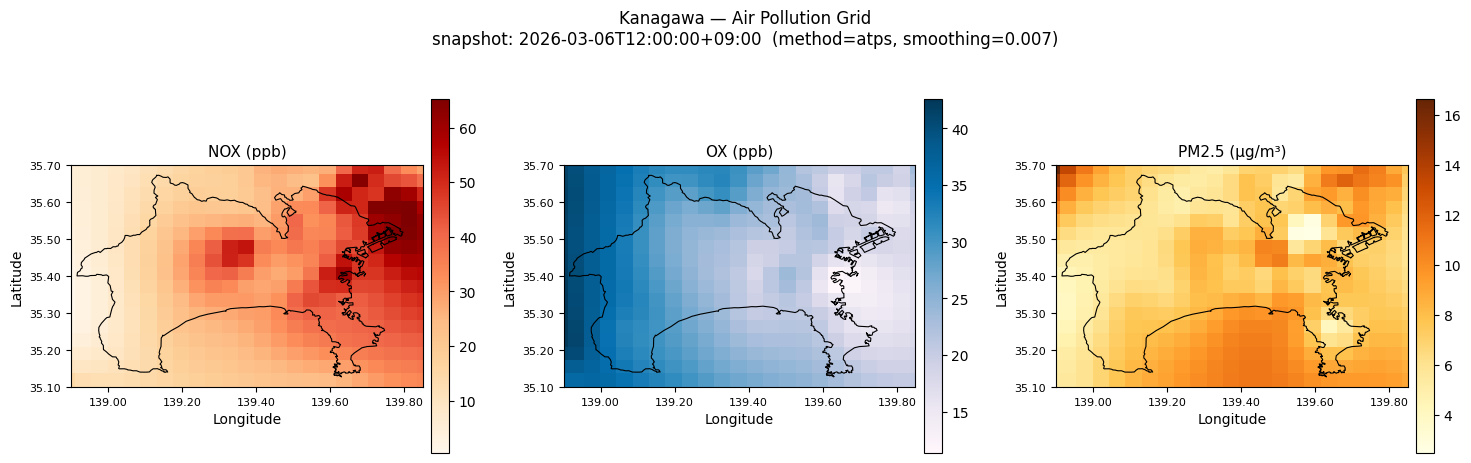

saved: kanagawa_grid.png


In [12]:
# ── プロット ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    f'Kanagawa — Air Pollution Grid\n'
    f'snapshot: {snapshot_at}  (method=atps, smoothing={SMOOTHING})',
    fontsize=12,
)

for ax, (lon2d, lat2d, field, _), title, cmap in zip(axes, datasets, TITLES, CMAPS):
    # 可視化用のみ 0 クランプ（負値は海上外挿アーティファクト）
    disp = np.where(field < 0, 0, field)

    pcm = ax.pcolormesh(lon2d, lat2d, disp, cmap=cmap, shading='nearest')
    fig.colorbar(pcm, ax=ax, orientation='vertical', pad=0.02, shrink=0.85)

    # 神奈川県の輪郭
    for ring in kanagawa_rings:
        ax.plot(ring[:, 0], ring[:, 1], color='black', linewidth=0.8, zorder=5)

    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.tick_params(labelsize=8)
    ax.set_xlim(138.9, 139.85)
    ax.set_ylim(35.1, 35.7)
    ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('kanagawa_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved: kanagawa_grid.png')